**--------------------------------------------------------RECURRENT NEURAL NETWORKS(RNNs)------------------------------------------------------**

 **Introduction to RNNs (Theory)**

 **What is Sequential Data?**

Sequential data refers to data where the **order of elements matters**. Each data point is dependent on previous ones. This is different from traditional data, where each sample is independent.

**Examples:**

* Text (sentences, paragraphs)
* Time series (weather, stock prices)
* Audio signals
* Video frames

In all these examples, the meaning or value of the current element depends on what came before it.

---

### RNN Architecture: Hidden State, Input, Output, and Time Steps

Recurrent Neural Networks are designed to work with sequential data by maintaining a **hidden state** that acts like memory.

#### Key components:

1. **Input (xᵗ)**: The input at time step *t*.
2. **Hidden state (hᵗ)**: Stores information about previous time steps. It gets updated at each step using the current input and previous hidden state.
3. **Output (yᵗ)**: The prediction or result from the current hidden state.
4. **Time steps**: Each position in the sequence corresponds to one time step.

**How it works**:
At each time step, the RNN takes the input and the hidden state from the previous time step, processes them, and produces a new hidden state and possibly an output.

---

### Difference Between RNN, LSTM, and GRU

| Model | Full Name                | Key Feature                                          | Advantage                                        |
| ----- | ------------------------ | ---------------------------------------------------- | ------------------------------------------------ |
| RNN   | Recurrent Neural Network | Basic memory through hidden state                    | Simple but struggles with long-term dependencies |
| LSTM  | Long Short-Term Memory   | Uses gates (input, forget, output) to control memory | Handles long-term dependencies better            |
| GRU   | Gated Recurrent Unit     | Simplified LSTM with fewer gates                     | Faster to train, performs similarly to LSTM      |

**Summary**:

* RNNs remember short-term patterns well.
* LSTMs and GRUs are more effective at learning from longer sequences due to better control of memory.

---

### Applications of RNNs

* **Language Modeling** (predicting next word)
* **Text Generation**
* **Speech Recognition**
* **Time Series Prediction**
* **Machine Translation**
* **Video Analysis**

Any task that involves understanding or predicting a sequence can benefit from RNNs or their variants.

---

## Intern Questions

**1. What makes RNNs suitable for sequential data?**
RNNs are designed to maintain memory through hidden states that update at each time step, allowing them to learn patterns across time or sequence.

**2. Why do we need to remember past inputs?**
In sequential data, the current element often depends on the previous ones. For example, in a sentence, the meaning of a word depends on the words before it.

**3. Where might a basic RNN fail?**
Basic RNNs struggle with:

* Long-term dependencies (they forget earlier information in long sequences)
* Vanishing or exploding gradients during training
* Learning long-range relationships (which LSTM and GRU handle better)

---

Complete RNN architecture from Scratch including forward and backword propagation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class VanillaRNN:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        """
        Initialize our RNN with random weights

        Think of this like setting up a brain with:
        - input_size: how many inputs we can receive at once
        - hidden_size: how much memory we have
        - output_size: how many outputs we produce
        """
        # Initialize weights randomly (small values to avoid exploding gradients)
        # Wxh: weights from input to hidden state (like: input -> memory)
        self.Wxh = np.random.randn(hidden_size, input_size) * 0.01

        # Whh: weights from previous hidden state to current hidden state (memory -> memory)
        self.Whh = np.random.randn(hidden_size, hidden_size) * 0.01

        # Why: weights from hidden state to output (memory -> output)
        self.Why = np.random.randn(output_size, hidden_size) * 0.01

        # Biases (like default settings for our neurons)
        self.bh = np.zeros((hidden_size, 1))  # hidden bias
        self.by = np.zeros((output_size, 1))  # output bias

        self.learning_rate = learning_rate
        self.hidden_size = hidden_size

    def forward_pass(self, inputs, h_prev):
        """
        Forward pass through the RNN for one sequence

        This is like reading a sentence word by word and remembering what we've seen
        inputs: sequence of inputs (like letters in a word)
        h_prev: what we remember from before (initial memory state)
        """
        # Storage for our journey through time
        xs, hs, ys, ps = {}, {}, {}, {}  # inputs, hidden states, outputs, probabilities

        # Start with previous hidden state (our initial memory)
        hs[-1] = np.copy(h_prev)
        loss = 0

        # Process each time step (like reading each letter in sequence)
        for t in range(len(inputs)):
            # Convert input to one-hot vector (like pointing to a letter in alphabet)
            xs[t] = np.zeros((vocab_size, 1))
            xs[t][inputs[t]] = 1  # Make the correct position = 1, others = 0

            # Calculate new hidden state (update our memory)
            # This is the core RNN equation: h_t = tanh(Wxh*x_t + Whh*h_{t-1} + bh)
            hs[t] = np.tanh(
                np.dot(self.Wxh, xs[t]) +      # current input contribution
                np.dot(self.Whh, hs[t-1]) +    # previous memory contribution
                self.bh                         # bias (default setting)
            )

            # Calculate output (what we predict)
            ys[t] = np.dot(self.Why, hs[t]) + self.by

            # Convert to probabilities using softmax (like confidence scores)
            ps[t] = np.exp(ys[t]) / np.sum(np.exp(ys[t]))

            # Calculate loss (how wrong we were)
            # We want high probability for correct answer, so we use -log(correct_probability)
            loss += -np.log(ps[t][targets[t], 0])

        return xs, hs, ys, ps, loss

    def backward_pass(self, xs, hs, ys, ps, targets):
        """
        Backward pass (learning from mistakes)

        This is like going back through our thought process and figuring out
        what we should have done differently
        """
        # Initialize gradients (these track how to improve our weights)
        dWxh = np.zeros_like(self.Wxh)  # how to change input->hidden weights
        dWhh = np.zeros_like(self.Whh)  # how to change hidden->hidden weights
        dWhy = np.zeros_like(self.Why)  # how to change hidden->output weights
        dbh = np.zeros_like(self.bh)    # how to change hidden bias
        dby = np.zeros_like(self.by)    # how to change output bias

        # This will accumulate errors flowing back through time
        dh_next = np.zeros_like(hs[0])

        # Go backwards through time (from last time step to first)
        for t in reversed(range(len(xs))):
            # Calculate output error (difference between what we predicted and what was correct)
            dy = np.copy(ps[t])
            dy[targets[t]] -= 1  # Subtract 1 from the correct answer's probability

            # Calculate how to change output weights
            dWhy += np.dot(dy, hs[t].T)
            dby += dy

            # Calculate error flowing back to hidden state
            dh = np.dot(self.Why.T, dy) + dh_next

            # Calculate error for hidden layer (before tanh activation)
            # tanh derivative: 1 - tanh²(x)
            dh_raw = (1 - hs[t] * hs[t]) * dh

            # Calculate how to change biases and weights
            dbh += dh_raw
            dWxh += np.dot(dh_raw, xs[t].T)
            dWhh += np.dot(dh_raw, hs[t-1].T)

            # Prepare error for next time step (going backwards)
            dh_next = np.dot(self.Whh.T, dh_raw)

        # Clip gradients to prevent exploding gradients (like putting a speed limit)
        for grad in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(grad, -5, 5, out=grad)

        return dWxh, dWhh, dWhy, dbh, dby

    def update_weights(self, dWxh, dWhh, dWhy, dbh, dby):
        """
        Update our weights based on what we learned

        This is like adjusting our thinking based on our mistakes
        """
        self.Wxh -= self.learning_rate * dWxh
        self.Whh -= self.learning_rate * dWhh
        self.Why -= self.learning_rate * dWhy
        self.bh -= self.learning_rate * dbh
        self.by -= self.learning_rate * dby

    def sample(self, seed_idx, n, h):
        """
        Generate new sequence based on what we learned

        This is like asking the RNN: "If I give you this starting letter,
        what do you think comes next?"
        """
        x = np.zeros((vocab_size, 1))
        x[seed_idx] = 1
        generated = []

        for t in range(n):
            # Forward pass for one step
            h = np.tanh(np.dot(self.Wxh, x) + np.dot(self.Whh, h) + self.bh)
            y = np.dot(self.Why, h) + self.by
            p = np.exp(y) / np.sum(np.exp(y))

            # Sample from probability distribution (pick next character based on confidence)
            ix = np.random.choice(range(vocab_size), p=p.ravel())

            # Prepare input for next iteration
            x = np.zeros((vocab_size, 1))
            x[ix] = 1
            generated.append(ix)

        return generated

Our vocabulary: ['a', 'c', 'd', 'b', 'e']
Character to index mapping: {'a': 0, 'c': 1, 'd': 2, 'b': 3, 'e': 4}

Training sequence:
Inputs:  ['a', 'b', 'c', 'd']
Targets: ['b', 'c', 'd', 'e']

Epoch 0, Loss: 6.4380
Epoch 100, Loss: 0.0798
Epoch 200, Loss: 0.0267
Epoch 300, Loss: 0.0157
Epoch 400, Loss: 0.0111
Epoch 500, Loss: 0.0085
Epoch 600, Loss: 0.0069
Epoch 700, Loss: 0.0058
Epoch 800, Loss: 0.0050
Epoch 900, Loss: 0.0044

Training completed!

=== Testing the RNN ===

Testing predictions:
Input: 'a' -> Predicted: 'b' (confidence: 0.999)
Input: 'b' -> Predicted: 'c' (confidence: 0.999)
Input: 'c' -> Predicted: 'd' (confidence: 0.999)
Input: 'd' -> Predicted: 'e' (confidence: 0.999)

=== Generating new sequence ===
Starting with 'a', generating 4 characters:
Generated: abcde


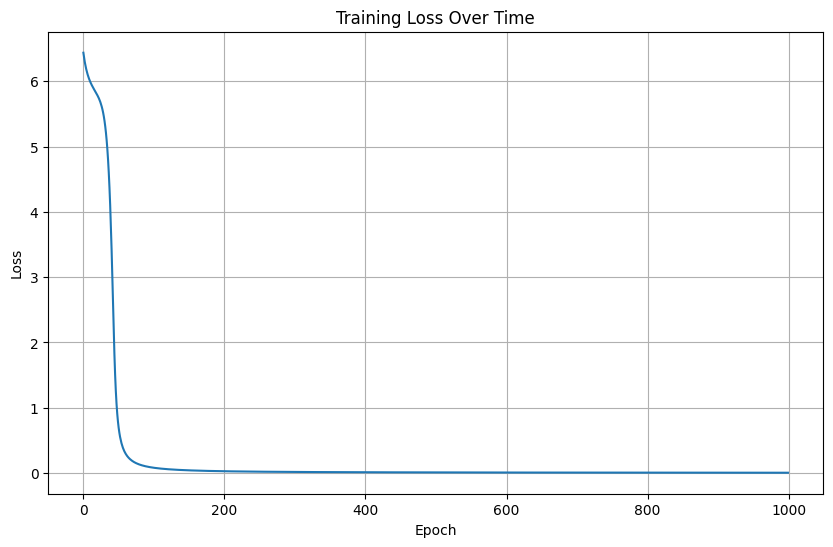


=== Understanding the RNN ===

1. Hidden State Evolution:
   - The hidden state is like the RNN's memory
   - It starts as zeros (no memory)
   - At each time step, it combines:
     * Current input (what we see now)
     * Previous hidden state (what we remember)
   - This creates a 'memory' that flows through time

2. Vanishing Gradient Problem:
   - When training, we calculate gradients (learning signals)
   - These gradients flow backwards through time
   - At each step, gradients get multiplied by weights
   - If weights are small, gradients shrink exponentially
   - Result: Early time steps barely learn anything
   - Solution: Use LSTM/GRU, gradient clipping, or better initialization


In [ ]:
# Create toy dataset: "abcde"
# We'll train the RNN to predict: a->b, b->c, c->d, d->e
data = "abcde"
chars = list(set(data))  # Get unique characters
vocab_size = len(chars)

# Create mappings between characters and numbers
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print("Our vocabulary:", chars)
print("Character to index mapping:", char_to_idx)
print()

# Prepare training data
# Input: [a, b, c, d], Target: [b, c, d, e]
inputs = [char_to_idx[ch] for ch in data[:-1]]   # All characters except last
targets = [char_to_idx[ch] for ch in data[1:]]   # All characters except first

print("Training sequence:")
print("Inputs: ", [idx_to_char[i] for i in inputs])
print("Targets:", [idx_to_char[i] for i in targets])
print()

# Initialize RNN
# input_size = vocab_size (we use one-hot encoding)
# hidden_size = 10 (how much memory we want)
# output_size = vocab_size (we predict probabilities for each character)
rnn = VanillaRNN(vocab_size, hidden_size=10, output_size=vocab_size, learning_rate=0.1)

# Training loop
losses = []
for epoch in range(1000):
    # Initialize hidden state (start with no memory)
    h_prev = np.zeros((rnn.hidden_size, 1))

    # Forward pass (make predictions)
    xs, hs, ys, ps, loss = rnn.forward_pass(inputs, h_prev)

    # Backward pass (learn from mistakes)
    dWxh, dWhh, dWhy, dbh, dby = rnn.backward_pass(xs, hs, ys, ps, targets)

    # Update weights (improve our model)
    rnn.update_weights(dWxh, dWhh, dWhy, dbh, dby)

    losses.append(loss)

    # Print progress every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

print("\nTraining completed!")

# Test the trained RNN
print("\n=== Testing the RNN ===")
h_test = np.zeros((rnn.hidden_size, 1))

# Test: give it 'a' and see if it predicts 'b'
print("\nTesting predictions:")
for i, char in enumerate(['a', 'b', 'c', 'd']):
    # Convert character to one-hot
    x = np.zeros((vocab_size, 1))
    x[char_to_idx[char]] = 1

    # Forward pass
    h_test = np.tanh(np.dot(rnn.Wxh, x) + np.dot(rnn.Whh, h_test) + rnn.bh)
    y = np.dot(rnn.Why, h_test) + rnn.by
    p = np.exp(y) / np.sum(np.exp(y))

    # Get prediction
    predicted_idx = np.argmax(p)
    predicted_char = idx_to_char[predicted_idx]
    confidence = p[predicted_idx, 0]

    print(f"Input: '{char}' -> Predicted: '{predicted_char}' (confidence: {confidence:.3f})")

# Generate new sequence
print("\n=== Generating new sequence ===")
print("Starting with 'a', generating 4 characters:")
h_gen = np.zeros((rnn.hidden_size, 1))
generated = rnn.sample(char_to_idx['a'], 4, h_gen)
generated_chars = ''.join([idx_to_char[i] for i in generated])
print(f"Generated: a{generated_chars}")

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

print("\n=== Understanding the RNN ===")
print("\n1. Hidden State Evolution:")
print("   - The hidden state is like the RNN's memory")
print("   - It starts as zeros (no memory)")
print("   - At each time step, it combines:")
print("     * Current input (what we see now)")
print("     * Previous hidden state (what we remember)")
print("   - This creates a 'memory' that flows through time")

print("\n2. Vanishing Gradient Problem:")
print("   - When training, we calculate gradients (learning signals)")
print("   - These gradients flow backwards through time")
print("   - At each step, gradients get multiplied by weights")
print("   - If weights are small, gradients shrink exponentially")
print("   - Result: Early time steps barely learn anything")
print("   - Solution: Use LSTM/GRU, gradient clipping, or better initialization")

**How does the hidden state evolve over time?**

In recurrent neural networks (RNNs), the **hidden state** acts as the network’s memory. It evolves over time by incorporating information from both the **previous hidden state** and the **current input** at each time step.

---
**Formula for RNN Hidden State Update:**

For a basic RNN, the hidden state at time step `t` is updated as:

$$
h_t = \tanh(W_h h_{t-1} + W_x x_t + b)
$$

Where:

* $h_t$ is the hidden state at time `t`
* $h_{t-1}$ is the hidden state from the previous time step
* $x_t$ is the current input
* $W_h, W_x$ are weight matrices
* $b$ is the bias term
* $\tanh$ is a non-linear activation function

---

### Evolution Over Time:

1. **At time `t=0`**:

   * The hidden state $h_0$ is often initialized to zero or a small random value.

2. **At each time step `t`**:

   * The RNN reads input $x_t$
   * Combines it with $h_{t-1}$
   * Produces new hidden state $h_t$
   * This $h_t$ is passed forward to the next step and also used to compute outputs.

---

### Role of Hidden State:

* **Memory**: It stores accumulated knowledge from previous time steps.
* **Context**: Helps the RNN "remember" relevant past data when making predictions.
* **Sequential Modeling**: Enables handling of time-dependent data, such as language, time series, etc.

---

### In LSTM / GRU:

In more advanced RNNs like **LSTM** or **GRU**, hidden state evolution includes **gating mechanisms** (input gate, forget gate, output gate) to better manage what information should be retained or forgotten — solving issues like the vanishing gradient problem.

---

If you'd like a step-by-step example using actual numbers or a visual timeline of hidden states evolving, I can provide that too.


 **What is the Vanishing Gradient Problem?**

The **vanishing gradient problem** occurs during the training of deep neural networks, especially in models like Recurrent Neural Networks (RNNs) and very deep feedforward networks.

---

 How it Happens:

When training a neural network using **backpropagation**, the network computes gradients (partial derivatives of the loss with respect to weights) to update the weights. These gradients are propagated backward through each layer.

In very deep networks, or in RNNs unrolled over many time steps:

* The gradient is repeatedly multiplied by the weights (which are often less than 1).
* After many layers/time steps, these gradients shrink exponentially.
* Eventually, they become so small that they approach zero.

This leads to **weights in the early layers receiving almost no updates**, slowing or completely halting learning.

---

### Why it’s a Problem:

* The network fails to **learn long-range dependencies**.
* The early layers (or early time steps in RNNs) **contribute little** to the final prediction.
* Training becomes **inefficient or impossible** for deep models.

---

### Typical Solutions:

1. **Use of better activation functions** like ReLU instead of sigmoid or tanh.
2. **Batch normalization** to stabilize training.
3. **LSTM/GRU** in RNNs to preserve gradients across long sequences.
4. **Residual connections** (used in ResNet) to allow gradients to flow directly through the network.

---

